# Smoking PheWAS Analysis

## Data Source
This notebook uses the smoking cohort file derived from All of Us Lifestyle survey responses together with demographic, EHR, and ancestry covariates from the prepared cohort dataset.

## Steps
- Load the prepared smoking cohort file (`smoking_cohort.tsv`)
- Generate phecode counts from ICD codes using the PheTK workflow
- Run a logistic-regression PheWAS with smoking case status as the exposure of interest
- Adjust for age, sex, EHR length, and ancestry principal components (PC1–PC5)
- Visualize the results with a Manhattan plot
- Review the top significant associations

## Results
The smoking PheWAS identified many significant associations, especially in phenotypes related to substance use, respiratory disease, and infectious disease. The strongest signals were in the expected direction and included nicotine dependence, alcohol-related disorders, substance use phenotypes, and chronic obstructive pulmonary disease.

## Output
This notebook produces `phecode_counts.tsv`, `smoking_phewas_results.tsv`, and `smoking_manhattan_plot.png` for downstream review and interpretation.

In [2]:
import pandas as pd
import os

cohort_df = pd.read_csv("smoking_cohort.tsv", sep="\t")
print(cohort_df.head())
print(cohort_df.shape)
print(cohort_df["case"].value_counts())
print(cohort_df.columns.tolist())

   person_id  age  ehr_length      pc_1      pc_2      pc_3      pc_4  \
0    1583400   48        1895  0.094543 -0.024477  0.028243  0.025669   
1    9518744   68        6394  0.099380  0.131129  0.010532  0.050819   
2    2097469   26         222  0.083695 -0.031694 -0.186943 -0.012876   
3    2916243   41         284  0.075633  0.020665 -0.125304  0.001577   
4    1190350   34        1023  0.095369  0.132594  0.010661  0.052256   

       pc_5  sex  case  
0 -0.001694    1     1  
1  0.002063    1     1  
2 -0.000677    1     0  
3  0.000184    1     1  
4  0.003133    1     0  
(219975, 10)
case
0    132265
1     87710
Name: count, dtype: int64
['person_id', 'age', 'ehr_length', 'pc_1', 'pc_2', 'pc_3', 'pc_4', 'pc_5', 'sex', 'case']


In [3]:
from phetk.phecode import Phecode
from phetk.phewas import PheWAS
from phetk.plot import Plot

In [4]:
from phetk.phecode import Phecode

phecode = Phecode(platform="aou")

phecode.count_phecode(
    phecode_version="X",
    icd_version="US",
    output_file_path="phecode_counts.tsv"
)

Start querying ICD codes...
Done!

Mapping ICD codes to phecodeX...
Successfully generated phecodeX counts for cohort participants!

Saved to phecode_counts.tsv



In [5]:
from phetk.phewas import PheWAS

phewas = PheWAS(
    phecode_version="X",
    phecode_count_file_path="phecode_counts.tsv",
    cohort_file_path="smoking_cohort.tsv",
    covariate_cols=["age", "sex", "ehr_length", "pc_1", "pc_2", "pc_3", "pc_4", "pc_5"],
    independent_variable_of_interest="case",
    sex_at_birth_col="sex",
    min_cases=50,
    min_phecode_count=2,
    method="logit",
    output_file_path="smoking_phewas_results.tsv"
)

phewas.run()

~~~~~~~~~~~~~~~~~~~~~~~~    Creating PheWAS Instance    ~~~~~~~~~~~~~~~~~~~~~~~~

Cohort size:  219975
case descriptions:  shape: (2, 2)
┌──────┬────────┐
│ case ┆ count  │
│ ---  ┆ ---    │
│ i64  ┆ u32    │
╞══════╪════════╡
│ 0    ┆ 132265 │
│ 1    ┆ 87710  │
└──────┴────────┘

Number of unique phecodes in cohort:  3507
Total number of phecode events:  16395576
Number of phecode batches to process:  3507

Analysis method:  Logistic regression

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~    Running PheWAS    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Parallelization method: multithreading
Number of workers: 5

Creating ThreadPoolExecutor...
Submitting jobs to workers...
Submitted 3507 jobs. Running regressions...


Processed: 100%|██████████| 3507/3507 [39:44<00:00,  1.47it/s] 


Multithreading completed successfully.
Combining 2436 result files...


Reading files: 100%|██████████| 2436/2436 [00:02<00:00, 885.00it/s] 


Concatenating results...
Cleaning up temporary files...


Cleaning files: 100%|██████████| 2436/2436 [00:00<00:00, 43438.79it/s]



~~~~~~~~~~~~~~~~~~~~~~~~~~~~    PheWAS Completed    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Number of participants in cohort: 219975
Number of phecodes in cohort: 3507
Number of phecodes having less than 50 cases or controls: 1071
Number of phecodes tested: 2436
Suggested Bonferroni correction (-log₁₀ scale): 4.687707279624819
Number of phecodes above Bonferroni correction: 604

PheWAS results saved to smoking_phewas_results.tsv 




Plot saved to smoking_manhattan_plot.png



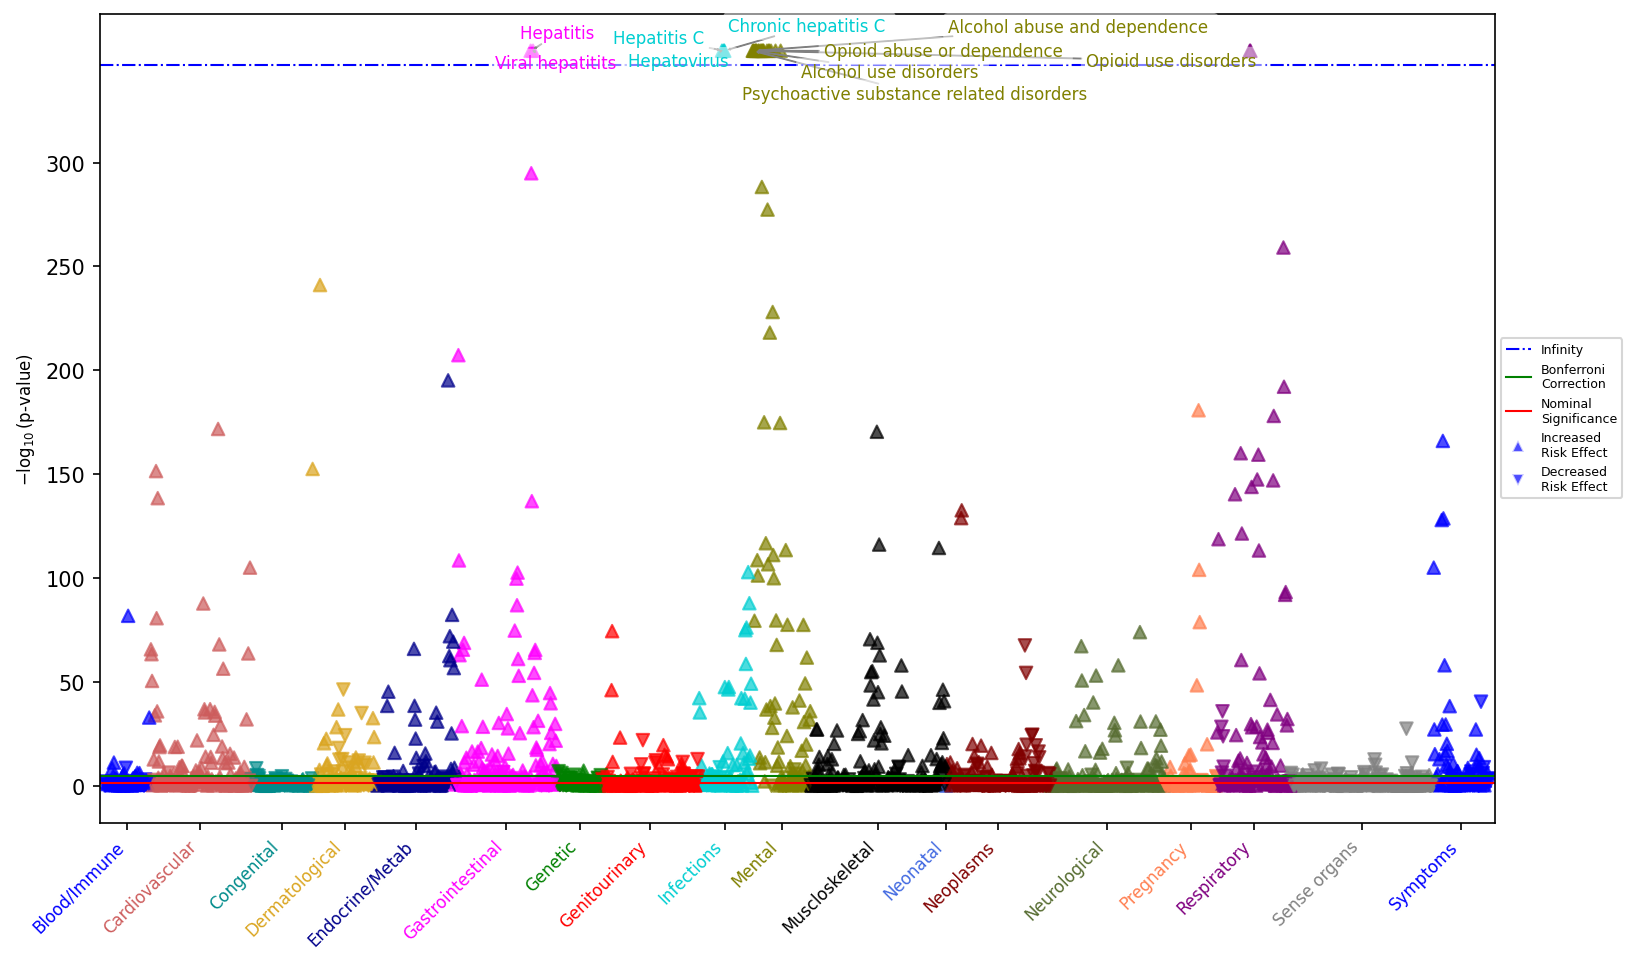

In [6]:
from phetk.plot import Plot

p = Plot("smoking_phewas_results.tsv", converged_only=True)

p.manhattan(
    label_values="p_value",
    label_count=10,
    save_plot=True,
    output_file_path="smoking_manhattan_plot.png"
)

In [7]:
import pandas as pd

results = pd.read_csv("smoking_phewas_results.tsv", sep="\t")
results_clean = results[results["converged"] == True].sort_values("p_value")
results_clean.head(20)

,phecode,cases,controls,p_value,neg_log_p_value,standard_error,beta,conf_int_1,conf_int_2,odds_ratio,log10_odds_ratio,converged,phecode_sex_restriction,phecode_string,phecode_category
1407,ID_054,6059,212024,0.0,inf,0.030,1.329512,1.271,1.388,3.779200,0.577400,True,Both,Hepatovirus,Infections
1112,MB_280.51,5398,212200,0.0,inf,0.037,1.997576,1.926,2.069,7.371166,0.867536,True,Both,Stimulant abuse or dependance,Mental
1571,GI_540,7454,209714,0.0,inf,0.026,1.124912,1.074,1.176,3.079945,0.488543,True,Both,Hepatitis,Gastrointestinal
1570,MB_290.1,9940,207402,0.0,inf,0.022,0.848479,0.806,0.891,2.336092,0.368490,True,Both,Posttraumatic stress disorder,Mental
1081,MB_282.2,20086,190588,0.0,inf,0.021,2.464958,2.423,2.507,11.762994,1.070518,True,Both,Personal history of nicotine dependence,Mental
263,MB_280.21,5610,211970,0.0,inf,0.035,1.944641,1.877,2.013,6.991123,0.844547,True,Both,Opioid abuse or dependence,Mental
549,ID_054.3,4819,214043,0.0,inf,0.036,1.677404,1.606,1.749,5.351646,0.728487,True,Both,Hepatitis C,Infections
464,MB_286,60622,147641,0.0,inf,0.010,0.568230,0.548,0.589,1.765140,0.246779,True,Both,Mood [affective] disorders,Mental
2094,MB_282,40938,166752,0.0,inf,0.016,3.020026,2.988,3.052,20.491832,1.311581,True,Both,Nicotine dependence (current and history of),Mental
298,MB_280.9,11873,203927,0.0,inf,0.023,1.639349,1.595,1.683,5.151815,0.711960,True,Both,Psychoactive substance dependance,Mental
